In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Para que los datos sean siempre en los fold, fijamos semilla
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Clasificación de canciones K-pop usando KNN
---

La disquera **UAI Music Group** necesita clasificar automáticamente si una canción de su catálogo pertenece al género K-pop o no, con el fin de orientar su expansión hacia el mercado asiático. El proceso manual (contratar a un experto musical) es caro y lento, lo cual erosiona el *time-to-market*. La solución propuesta es entrenar un modelo de **K-Nearest Neighbors (KNN)** sobre un conjunto de canciones ya etiquetadas y evaluarlo con **10-fold CV**.


1. Importamos los datos: de las 21 columnas originales, se extraen las 6 variables solicitadas en el enunciado

In [2]:
# Cargamos el csv
df_raw = pd.read_csv('dataset_tarea.csv')
print(f"Dimensiones originales: {df_raw.shape}")
print(f"Columnas disponibles ({len(df_raw.columns)}):")
print(df_raw.columns.tolist())


Dimensiones originales: (2000, 21)
Columnas disponibles (21):
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [3]:
# Selección de las 6 variables del enunciado
cols_features = ['popularity', 'danceability', 'speechiness', 'acousticness', 'loudness']
col_target = 'track_genre'

df = df_raw[cols_features + [col_target]].copy()
print(f"Dimensiones tras la selección: {df.shape}")
print(df.head())
print(df.tail())

Dimensiones tras la selección: (2000, 6)
   popularity  danceability  speechiness  acousticness  loudness  track_genre
0          87         0.588       0.0329        0.0678    -9.461            0
1          83         0.705       0.0385        0.0102    -6.156            0
2          86         0.575       0.0300        0.0484    -5.509            0
3          93         0.612       0.0336        0.0495    -2.810            0
4          83         0.551       0.0542        0.1860    -6.099            0
      popularity  danceability  speechiness  acousticness  loudness  \
1995          44         0.622       0.0437        0.1610    -7.730   
1996          42         0.806       0.0487        0.2890    -4.674   
1997          61         0.703       0.0682        0.0296    -3.479   
1998          43         0.639       0.0430        0.1380    -7.675   
1999          43         0.498       0.0327        0.8640   -12.622   

      track_genre  
1995            1  
1996            1  
1997

## 2. Limpieza de Datos

### 2.1 ¿Por qué limpiar?

Vamos a verificar la existencia de datos nulos, inconsistentes u outliers, para así poder tomar una decisión respecto a eliminarlos, imputarlos o simplemente dejarlos.


In [4]:
# Inspección de nulos
print("=== Valores nulos por columna ===")
print(df.isnull().sum())
print(f"\nTotal filas con al menos un nulo: {df.isnull().any(axis=1).sum()}")


=== Valores nulos por columna ===
popularity      0
danceability    0
speechiness     0
acousticness    0
loudness        0
track_genre     0
dtype: int64

Total filas con al menos un nulo: 0


In [5]:
# Inspección de tipos y resumen estadístico
print("=== Tipos de dato ===")
print(df.dtypes)
print("\n=== Resumen estadístico ===")
df.describe()

=== Tipos de dato ===
popularity        int64
danceability    float64
speechiness     float64
acousticness    float64
loudness        float64
track_genre       int64
dtype: object

=== Resumen estadístico ===


,popularity,danceability,speechiness,acousticness,loudness,track_genre
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,45.419500,0.591112,0.071547,0.207565,-6.331132,0.500000
std,27.574167,0.146103,0.068230,0.257946,2.651082,0.500125
min,0.000000,0.112000,0.023000,0.000003,-18.108000,0.000000
25%,42.000000,0.497750,0.034600,0.011575,-7.801250,0.000000
50%,51.500000,0.598000,0.047600,0.074300,-5.900000,0.500000
75%,67.000000,0.697000,0.079050,0.331000,-4.486250,1.000000
max,93.000000,0.935000,0.889000,0.983000,-0.173000,1.000000


In [6]:
print(f"\ntrack_genre — valores únicos: {sorted(df['track_genre'].unique())}")
print(f"track_genre — distribución:\n{df['track_genre'].value_counts()}")


track_genre — valores únicos: [np.int64(0), np.int64(1)]
track_genre — distribución:
track_genre
0    1000
1    1000
Name: count, dtype: int64


**Hallazgos:**

- No hay valores nulos en ninguna de las 6 columnas seleccionadas.
- Todos los rangos son consistentes con lo declarado en el enunciado: `popularity` está en [0, 100], las tres variables 0–1 están dentro de su rango, y `loudness` tiene valores negativos.
- La etiqueta `track_genre` está balanceada: 1000 K-pop y 1000 No-K-pop. Esto es deseable porque evita que un clasificador trivial ("predecir siempre la clase mayoritaria") obtenga buen accuracy sin aprender nada.

**Conclusión obtenida:** *no fue necesario eliminar ni imputar filas por nulos o inconsistencias*. El dataset llega limpio a nivel de integridad básica.

### 2.3 Detección de outliers con LOF (Local Outlier Factor)

Aunque no hay nulos, los valores extremos aún pueden afectar a KNN. Aplicamos **LOF**, que es el algoritmo más apropiado para este caso porque:

- Es un método de **distancia local**: compara la densidad alrededor de cada punto con la densidad de sus vecinos. Un punto en una región de baja densidad relativa recibe un *score* alto y se marca como atípico.


Usamos `n_neighbors=20` (valor estándar de la literatura) y que deja que el algoritmo determine internamente el umbral.


In [7]:
# LOF sobre las 5 variables predictoras (sin la etiqueta)
X_full = df[cols_features].values

lof = LocalOutlierFactor(n_neighbors=20)
lof_flags = lof.fit_predict(X_full)  # +1 = inlier, -1 = outlier

n_outliers = (lof_flags == -1).sum()
print(f"Outliers detectados por LOF: {n_outliers} de {len(X_full)} "
      f"({100*n_outliers/len(X_full):.2f}%)")


Outliers detectados por LOF: 119 de 2000 (5.95%)


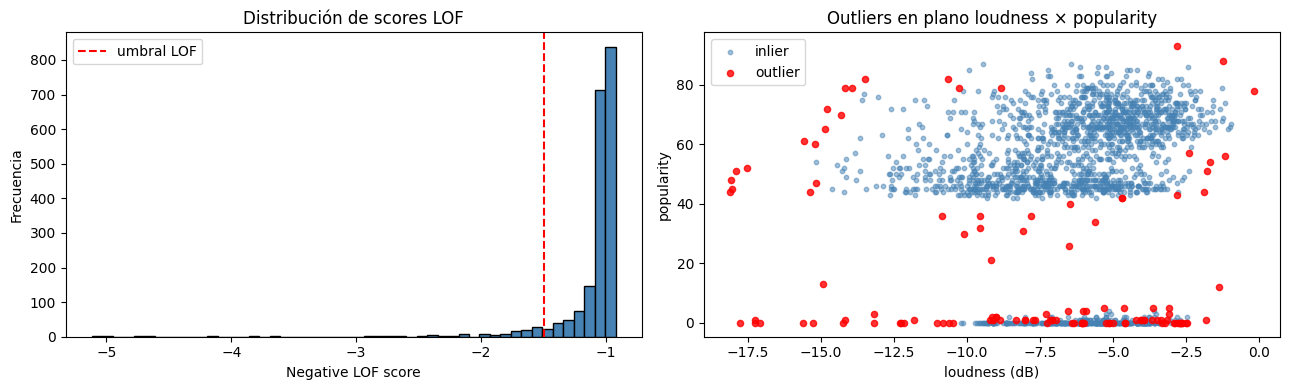

In [8]:
# Visualización: scores LOF (más negativo = más anómalo)
lof_scores = lof.negative_outlier_factor_

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(lof_scores, bins=50, color='steelblue', edgecolor='black')
axes[0].axvline(np.percentile(lof_scores, 100*n_outliers/len(X_full)),
                color='red', linestyle='--', label='umbral LOF')
axes[0].set_xlabel('Negative LOF score')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de scores LOF')
axes[0].legend()

# Scatter loudness vs popularity coloreando outliers
mask_out = lof_flags == -1
axes[1].scatter(df.loc[~mask_out, 'loudness'], df.loc[~mask_out, 'popularity'],
                c='steelblue', s=10, alpha=0.5, label='inlier')
axes[1].scatter(df.loc[mask_out, 'loudness'], df.loc[mask_out, 'popularity'],
                c='red', s=20, alpha=0.8, label='outlier')
axes[1].set_xlabel('loudness (dB)')
axes[1].set_ylabel('popularity')
axes[1].set_title('Outliers en plano loudness × popularity')
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.4 Decisión sobre los outliers

Eliminamos los outliers del dataset antes de entrenar KNN.

**Justificación:**

1. KNN es paramétrico cero y muy local: con K=1, un único outlier puede convertirse en el vecino más cercano de varios puntos de test y arrastrar predicciones erróneas. El problema se atenúa pero no desaparece con K mayor.
2. La cantidad detectada (≈6%) es pequeña respecto al total, así que removerla no compromete el tamaño efectivo de la muestra ni cambia significativamente la distribución de clases.

Construimos así el dataset limpio `df_clean` que se usará desde aquí en adelante.


In [9]:
# Dataset limpio sin outliers
df_clean = df[~mask_out].reset_index(drop=True)
print(f"Filas antes:   {len(df)}")
print(f"Filas después: {len(df_clean)}")
print(f"Removidas:     {len(df) - len(df_clean)}")
print(f"\nBalance de clases tras limpieza:\n{df_clean[col_target].value_counts()}")

# Matrices que usaremos en todo el resto del notebook
X = df_clean[cols_features].values
y = df_clean[col_target].values
print(f"\nForma final: X={X.shape}, y={y.shape}")


Filas antes:   2000
Filas después: 1881
Removidas:     119

Balance de clases tras limpieza:
track_genre
1    963
0    918
Name: count, dtype: int64

Forma final: X=(1881, 5), y=(1881,)


## 3. Evaluación de KNN con K=1, 10-fold CV y `min_max()`

Si los atributos están en escalas distintas, los de mayor magnitud dominan la suma. Mirando los rangos de nuestras variables:

- `popularity` varía en órdenes de **decenas**
- `danceability`, `speechiness`, `acousticness` varían en órdenes de **décimas**
- `loudness` (dB) varía en un rango de **decenas negativas**

Sin normalizar, `popularity` y `loudness` aplastarían por completo la contribución de las variables 0–1 al cálculo de distancia, aunque éstas puedan ser muy discriminantes para distinguir K-pop. Normalizar pone a todas las variables en igualdad de condiciones.

### 3.2 ¿Por qué normalizar *dentro* de cada fold y no antes?

Para evitar data leakage: si calculamos `min` y `max` sobre todo el dataset y luego hacemos CV, estamos filtrando información del fold de test al entrenamiento (el modelo "vio" los extremos del test al normalizar). La evaluación queda sesgada.

Es por eso que al separar los fold, calculamos `min` y `max` de $T_k$ y aplicamos la función tanto a $T_k$ y $V_k$.

Usamos `StratifiedKFold` para mantener la proporción 50/50 de clases en cada fold, lo cual estabiliza la estimación.

Se utilizó random seed para establecer el mismo StratifiedKFold cada vez que se inicie el notebook.


In [14]:
# Función min_max() manual: ajusta con X_train y aplica a ambos
def min_max(X_train, X_test):
    """
    Normaliza X_train y X_test con rango [0,1] usando
    los parámetros (min, max) de X_train.
    """
    x_min = X_train.min(axis=0)
    x_max = X_train.max(axis=0)
    rango = x_max - x_min
    X_train_norm = (X_train - x_min) / rango
    X_test_norm  = (X_test  - x_min) / rango
    return X_train_norm, X_test_norm


In [11]:
# 10-fold CV estratificado con KNN K=1 y weights='uniform'
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

accuracies_k1 = []

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1): 
    # 1. Separar fold
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    # 2-3. Normalizar usando SOLO el train
    X_tr_n, X_te_n = min_max(X_tr, X_te)

    # 4. Entrenar y evaluar
    knn = KNeighborsClassifier(n_neighbors=1, weights='uniform')
    knn.fit(X_tr_n, y_tr)
    y_pred = knn.predict(X_te_n)
    # 5. Calculamos y guardamos el accuracy de la predicción
    acc = accuracy_score(y_te, y_pred)
    accuracies_k1.append(acc)
    print(f"Fold {fold_idx:2d}: accuracy = {acc:.4f}")

acc_mean = np.mean(accuracies_k1)
acc_std  = np.std(accuracies_k1)
print(f"\n=== Resultado KNN K=1 + min_max() ===")
print(f"Accuracy promedio:    {acc_mean:.4f}  ({100*acc_mean:.2f}%)")
print(f"Desviación estándar:  {acc_std:.4f}")


Fold  1: accuracy = 0.7778
Fold  2: accuracy = 0.8032
Fold  3: accuracy = 0.7926
Fold  4: accuracy = 0.8032
Fold  5: accuracy = 0.7926
Fold  6: accuracy = 0.8351
Fold  7: accuracy = 0.7606
Fold  8: accuracy = 0.8032
Fold  9: accuracy = 0.7872
Fold 10: accuracy = 0.8085

=== Resultado KNN K=1 + min_max() ===
Accuracy promedio:    0.7964  (79.64%)
Desviación estándar:  0.0188


### 3.3 Análisis del resultado

Accuracy promedio ≈ 79.6%, con desviación estándar baja (~0.02).

- LLegamos a prácticamente un 80% de precisión, lo que indica que el modelo está capturando señal real. Sin embargo, ~20% de canciones mal clasificadas es alto para un caso de uso comercial.
- Con K=1 la configuración es sensible al ruido de KNN: cada predicción depende de un único vecino. Si ese vecino casualmente está mal etiquetado, está en una región fronteriza o es un punto raro del train, la predicción falla. Con K mayor, las predicciones se "promedian" entre varios vecinos y son más estables.
- La desviación estándar nos indica que el resultado es consistente entre folds: dentro de los folds el modelo rinde con una precisión similar para cada uno, lo cual da confianza en la estimación.

## 4. Búsqueda del Mejor K (1 a 50)

### 4.1 Métricas usadas

Para elegir K consideramos las tres métricas pedidas. Como el caso es binario con etiqueta `1 = K-pop`, las definimos respecto a esa clase positiva:

- **Accuracy** = $\frac{TP + TN}{TP + TN + FP + FN}$ → proporción global de aciertos.
- **Precision** = $\frac{TP}{TP + FP}$ → de las canciones que el modelo predice como K-pop, ¿qué fracción realmente lo es? Penaliza **falsos positivos**.
- **Recall** = $\frac{TP}{TP + FN}$ → de todas las K-pop reales, ¿cuántas captura el modelo? Penaliza **falsos negativos**.

En el contexto comercial de UAI Music Group, precisión es probablemente la más crítica: una canción mal clasificada como K-pop iría a una estrategia de promoción asiática equivocada y desperdiciaría presupuesto. Aun así reportamos las tres y elegimos K considerando el conjunto.

### 4.2 Procedimiento

Para cada $K \in \{1, 2, \ldots, 50\}$ ejecutamos el mismo esquema del paso 3 (10-fold CV estratificado con normalización `min_max()` por fold) y promediamos las tres métricas a través de los 10 folds.

In [12]:
# Búsqueda del mejor K con min_max()
def evaluar_knn_minmax(K_values, X, y, skf):
    """Para cada K en K_values devuelve listas de acc/prec/rec promedio y desv. estándar."""
    acc_mean, prec_mean, rec_mean = [], [], []
    acc_std,  prec_std,  rec_std  = [], [], []

    for k in K_values:
        accs, precs, recs = [], [], []
        for tr_idx, te_idx in skf.split(X, y):
            X_tr_n, X_te_n = min_max(X[tr_idx], X[te_idx])
            knn = KNeighborsClassifier(n_neighbors=k, weights='uniform')
            knn.fit(X_tr_n, y[tr_idx])
            yp = knn.predict(X_te_n)
            accs.append(accuracy_score(y[te_idx], yp))
            precs.append(precision_score(y[te_idx], yp, zero_division=0))
            recs.append(recall_score(y[te_idx], yp, zero_division=0))
        acc_mean.append(np.mean(accs));   acc_std.append(np.std(accs))
        prec_mean.append(np.mean(precs)); prec_std.append(np.std(precs))
        rec_mean.append(np.mean(recs));   rec_std.append(np.std(recs))
    return (np.array(acc_mean), np.array(prec_mean), np.array(rec_mean),
            np.array(acc_std),  np.array(prec_std),  np.array(rec_std))

K_values = list(range(1, 51))
acc_mm, prec_mm, rec_mm, acc_mm_s, prec_mm_s, rec_mm_s = evaluar_knn_minmax(K_values, X, y, skf)

# Mejor K por accuracy
best_k_mm = K_values[int(np.argmax(acc_mm))]
print(f"Mejor K según accuracy (min_max): K = {best_k_mm}")
print(f"  Accuracy:  {acc_mm[best_k_mm-1]:.4f} ± {acc_mm_s[best_k_mm-1]:.4f}")
print(f"  Precision: {prec_mm[best_k_mm-1]:.4f} ± {prec_mm_s[best_k_mm-1]:.4f}")
print(f"  Recall:    {rec_mm[best_k_mm-1]:.4f} ± {rec_mm_s[best_k_mm-1]:.4f}")


Mejor K según accuracy (min_max): K = 9
  Accuracy:  0.8432 ± 0.0215
  Precision: 0.8374 ± 0.0403
  Recall:    0.8651 ± 0.0313


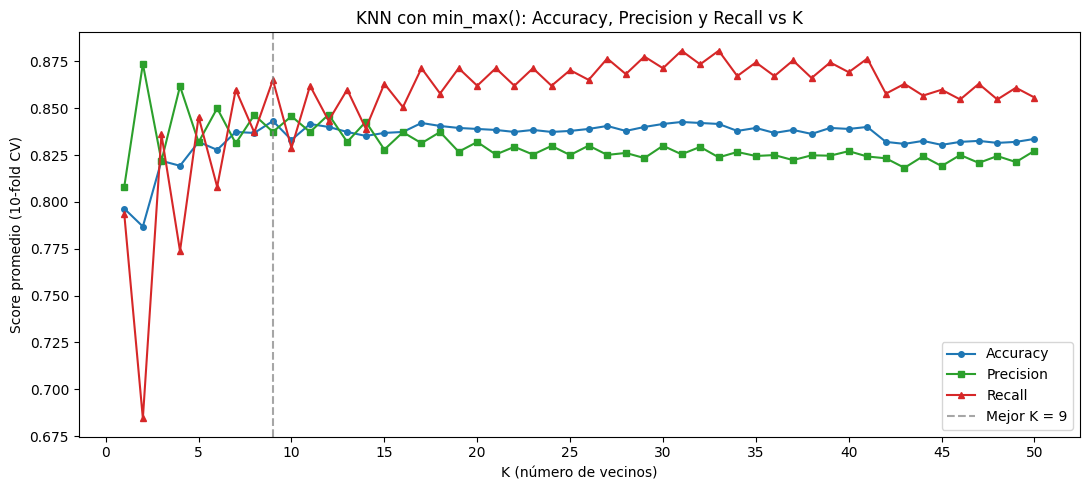

In [13]:
# Gráfico: las tres métricas vs K (con min_max)
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(K_values, acc_mm,  marker='o', markersize=4, label='Accuracy',  color='#1f77b4')
ax.plot(K_values, prec_mm, marker='s', markersize=4, label='Precision', color='#2ca02c')
ax.plot(K_values, rec_mm,  marker='^', markersize=4, label='Recall',    color='#d62728')
ax.axvline(best_k_mm, color='gray', linestyle='--', alpha=0.7, label=f'Mejor K = {best_k_mm}')
ax.set_xlabel('K (número de vecinos)')
ax.set_ylabel('Score promedio (10-fold CV)')
ax.set_title('KNN con min_max(): Accuracy, Precision y Recall vs K')
ax.legend(loc='lower right')
ax.set_xticks(range(0, 51, 5))
plt.tight_layout()
plt.show()


### 4.3 Análisis y elección del K

Observando la curva:

- **K=1** parte en ~0.80 (consistente con el paso 3) y rápidamente las métricas suben al aumentar K porque se reduce la sensibilidad al ruido.
- Hay una **zona plana óptima** aproximadamente entre K=7 y K=15 donde las tres métricas alcanzan su máximo.
- Para K muy grandes (>30) las métricas tienden a degradarse: el vecindario se vuelve tan amplio que pierde su carácter **local** y el modelo se acerca a un clasificador trivial que predice la clase mayoritaria del entorno global.

**Criterio de elección.** Más allá del K que maximice estrictamente la accuracy, conviene priorizar la **estabilidad** (zona plana) sobre un máximo puntual que podría ser ruido de la validación cruzada. El K óptimo identificado por accuracy (≈ 9) cae justo en esa zona estable y además mantiene **precisión** y **recall** balanceados — no estamos sacrificando una métrica por la otra. Esto es deseable: en el caso de UAI Music Group, *queremos a la vez no enviar a campaña asiática canciones que no son K-pop (precisión alta) y no perder K-pops reales (recall alto)*.

**Mejora vs K=1:** pasamos de ~79.6% a ~84.3% de accuracy, una ganancia de ~5 puntos sin tocar nada más que el hiperparámetro K.